In [1]:
from plottr.data.datadict_storage import datadict_from_hdf5
import numpy as np
import matplotlib.pyplot as plt
import lmfit

In [2]:
import sklearn
from sklearn.decomposition import PCA

In [3]:
header = "D:/K_sunada/result/CDY159/"
current = "/2024-05-29/2024-05-29T182009_a519864e-cw_JPA_current_vs_freq"
dd = datadict_from_hdf5(header + current +"/data")

In [4]:
def PCA_transform(Re_c, Im_c):
    pca = PCA()
    c_data = np.concatenate([np.array([Re_c]).T, np.array([Im_c]).T], axis = 1)
    pca.fit(c_data)
    c_pca = pca.transform(c_data)
    c_PCA1 = c_pca.T[0]
    c_PCA2 = c_pca.T[1]
    return c_PCA1, c_PCA2

In [5]:
x = np.unique(dd['current']['values'])
y = np.unique(dd['frequency']['values'])
z = dd['s11']['values']/dd['s11']['values'][-1]

In [6]:
z.shape

(21, 401)

C:\Users\qipe\AppData\Local\Temp\ipykernel_9832\1189632422.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cm = plt.cm.get_cmap('magma')


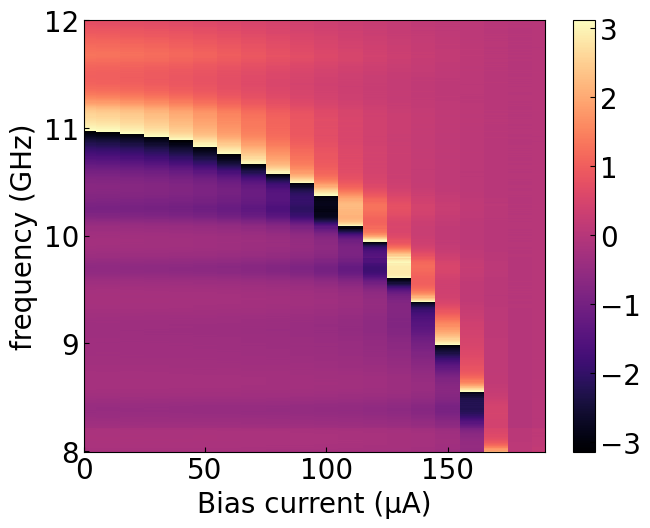

In [7]:
cm = plt.cm.get_cmap('magma')
fig= plt.figure()
plt.rcParams["font.size"] = 20
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
ax = fig.add_axes((0.1, 0.1, 0.9, 0.9))
ax.set_xlabel("Bias current (μA)")
ax.set_ylabel("frequency (GHz)")
ax.set_xlim(0, 190)

maingraph = ax.pcolormesh(x,y, np.angle(z).reshape(21, 401).T, vmin=min(np.unique(np.angle(z))), vmax=max(np.unique(np.angle(z))), cmap=cm, shading='auto')
plt.colorbar(maingraph)
plt.show()

In [8]:
def S11_resonator(freq, fc, ke, ki, a0, a1, Poff, ed):
    numer = 1j*(freq-fc)+(ke-ki)/2
    denom = 1j*(freq-fc)-(ke+ki)/2
    model = (numer/denom * (a0+a1*(freq-freq[0])) * np.exp(1j*(-Poff-ed*2*np.pi*freq))).conj()
    return model

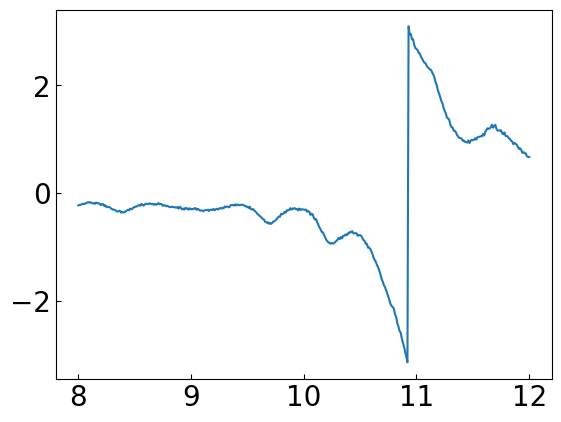

In [9]:
plt.plot(y, np.angle(z[3]))
plt.show()

In [10]:
par_ini = {
    'fc':8.5,
    'ke':0.1,
    'ki':0.0002,
    'a0':0.96,
    'a1':0,
    'Poff':0.26,
    'ed':0,
}

par_min = {
    'fc':0,
    'ke':0,
    'ki':0,
    'a0':0,
    'a1':- np.inf,
    'Poff':- np.pi,
    'ed':- np.inf,
}

par_max = {
    'fc':np.inf,
    'ke':np.inf,
    'ki':np.inf,
    'a0':np.inf,
    'a1':np.inf,
    'Poff':np.pi,
    'ed':np.inf,
}

par_vary = {
    'fc':True,
    'ke':True,
    'ki':True,
    'a0':True,
    'a1':False,
    'Poff':True,
    'ed':True,
}

In [11]:
model = lmfit.Model(S11_resonator)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )

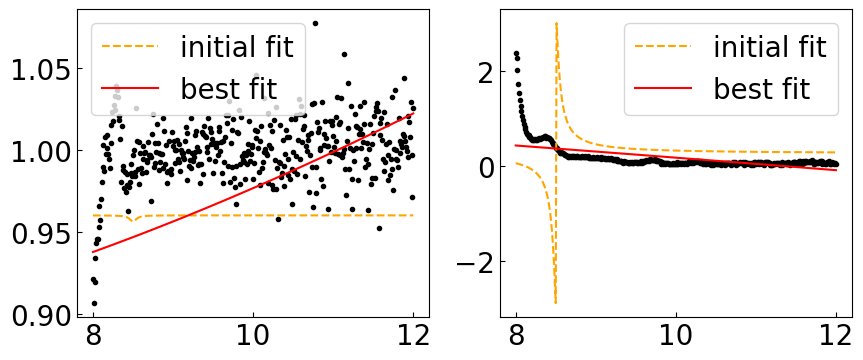

In [12]:
s11 = z[17]
res = model.fit(data = s11, params = params, freq = y)

fig, ax = plt.subplots(1,2,figsize=(10,4))
ax[0].plot(y, np.abs(s11), '.', color='k')
ax[0].plot(y, np.abs(res.init_fit), '--', label='initial fit', color='orange')
ax[0].plot(y, np.abs(res.best_fit), '-', label='best fit', color='red')
ax[0].legend()
ax[1].plot(y, np.angle(s11), '.', color='k')
ax[1].plot(y, np.angle(res.init_fit), '--', label='initial fit', color='orange')
ax[1].plot(y, np.angle(res.best_fit), '-', label='best fit', color='red')
ax[1].legend()


plt.show()
res

In [13]:
fc = [10.9609180, 10.9544046, 10.9376170, 10.9088592, 10.8685969, 10.8157880,
      10.7496105, 10.6701509, 10.5739086, 10.4588032, 10.3123871, 10.1310932,
      9.94307101, 9.69015623, 9.39415889, 9.01647402, 8.55668338]

In [14]:
20*np.log10(7)

16.901960800285135

C:\Users\qipe\AppData\Local\Temp\ipykernel_3812\1532769228.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cm = plt.cm.get_cmap('magma')


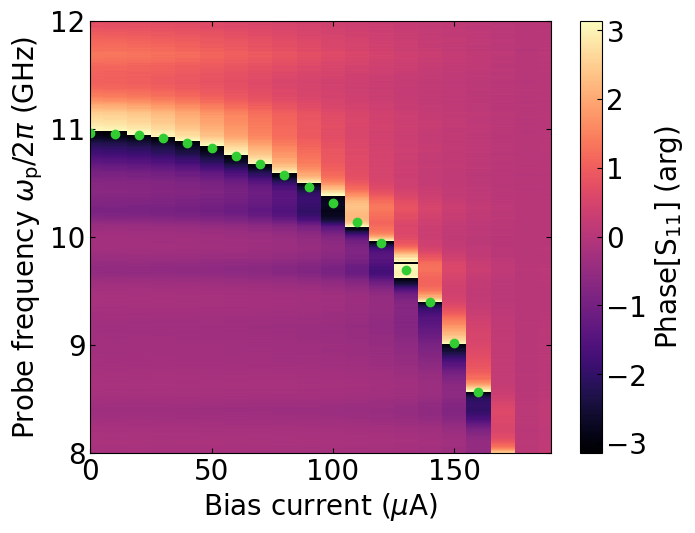

In [15]:
cm = plt.cm.get_cmap('magma')
fig= plt.figure()
plt.rcParams["font.size"] = 20
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
ax = fig.add_axes((0.1, 0.1, 0.9, 0.9))
ax.set_xlabel("Bias current ($\mu$A)")
ax.set_ylabel("Probe frequency $\omega_\mathrm{p}/2\pi$ (GHz)")
ax.set_xlim(0, 190)
ax.set_ylim(8.0, 12.0)

maingraph = ax.pcolormesh(x,y, np.angle(z).reshape(21, 401).T, vmin=min(np.unique(np.angle(z))), vmax=max(np.unique(np.angle(z))), cmap=cm, shading='auto')
plt.colorbar(maingraph, label="Phase[S$_{11}$] (arg)")
plt.tick_params(top='on',bottom='on',left='on',right='on')
fc = [10.9609180, 10.9544046, 10.9376170, 10.9088592, 10.8685969, 10.8157880,
      10.7496105, 10.6701509, 10.5739086, 10.4588032, 10.3123871, 10.1310932,
      9.94307101, 9.69015623, 9.39415889, 9.01647402, 8.55668338]
plt.plot(x[0:17], fc, 'o',color='limegreen')
# plt.savefig('JPA_cw_current.png', bbox_inches='tight')
plt.show()



In [16]:
data = "/2024-02-17/2024-02-17T165841_5da003f1-cw_JPA_gain_amp"
dd = datadict_from_hdf5(header + data +"/data")

In [17]:
s11 = dd["s11"]["values"]
freq =dd["frequency"]["values"]
Gain= 20 * np.log10(np.abs(s11))

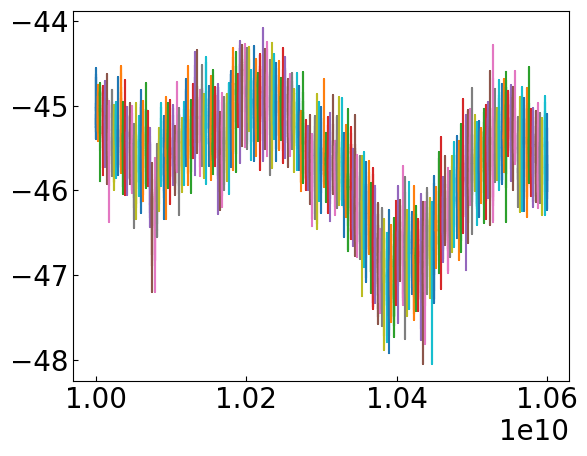

In [18]:
plt.plot(freq, Gain)

JPA calibration

In [8]:
pump ="/2024-05-29/2024-05-29T182705_9cd8d1a0-cw_JPA_gain_amp"
dd = datadict_from_hdf5(header + pump +"/data")

In [9]:
dd

Gain: (14, 201)
  ⌙ frequency (GHz): (14, 201)
  ⌙ amplitude (V): (14,)
s11: (14, 201)
  ⌙ frequency (GHz): (14, 201)
  ⌙ amplitude (V): (14,)
s11_per_base: (14, 201)
  ⌙ frequency (GHz): (14, 201)
  ⌙ amplitude (V): (14,)

4.17473109035466 0.4
6.394680608448651 0.5
9.209394686877957 0.6
13.319657238321245 0.7000000000000001
20.022452854710707 0.8


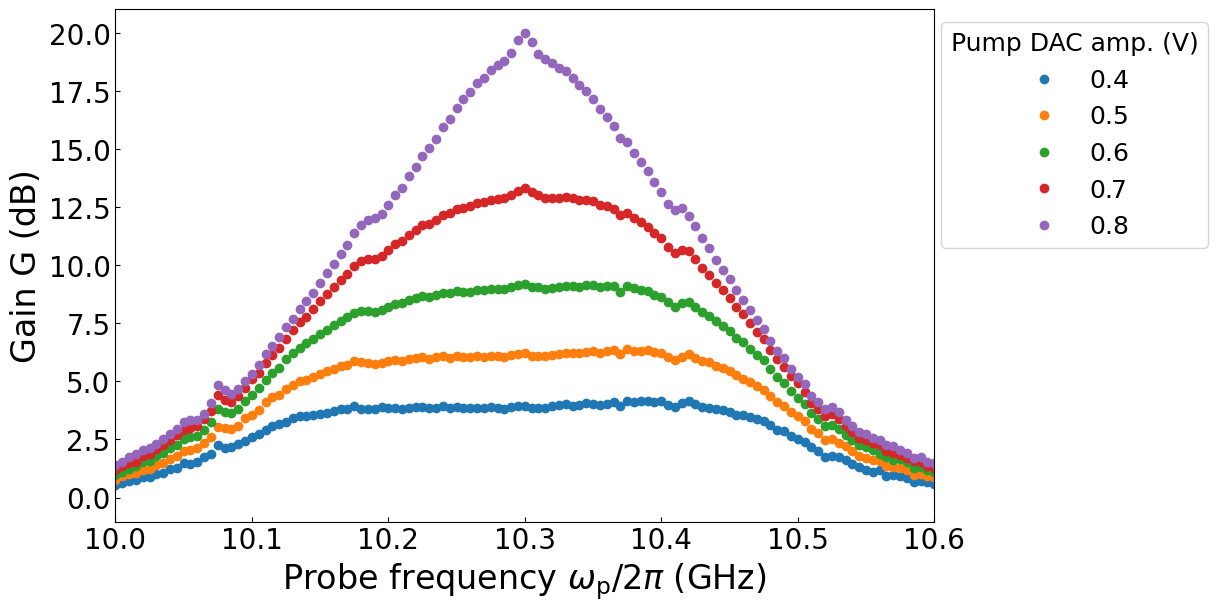

In [10]:
id = 1

fig, ax = plt.subplots(figsize=(12,6),constrained_layout=True)
plt.rcParams["font.size"] = 20
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
for id in range(5):
    id = id + 3
    x = dd['frequency']['values'][id]
    y = dd['amplitude']['values'][id]
    z = 20 * np.log10(np.abs(dd['s11_per_base']['values'][id]))
    plt.plot(x*1e-9, z, 'o', label = r"${}$".format(np.round(y, 2)))
    print(np.max(z), y)

plt.title("")

legend = plt.legend(title_fontsize=18, fontsize=18, loc='upper right', bbox_to_anchor=(1.35, 1))
legend.set_title("Pump DAC amp. (V)")
ax.set_xlabel('Probe frequency $\omega_\mathrm{p}/2\pi$ (GHz)', size='large')
ax.set_ylabel('Gain G (dB)', size='large')
ax.set_xlim(10, 10.6)
# plt.savefig('JPA_cw_pump.png', bbox_inches='tight')
plt.show()

# plt.plot(np.linspace(10e9, 10.6e9, 1000), np.linspace(10.32, 10.32, 1000))